# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Seven trials recorded; best is trial 05 (0.0196) with trial 07 (0.0205) statistically tied. Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205. The campaign has converged on a plateau: the two best trials bracket the optimum tightly at lr_mu ~27, sigma_ref ~6.2-6.3, lr_gamma ~0.41-0.42, gamma_anneal ~0.39-0.42, and both hit the same mu floor (rel RMSE 15.3%). lr_mu peaks near 27 and sigma_ref is monotone (smaller is better, saturated below ~6.3); gamma is only weakly sensitive to lr_gamma and gamma_anneal. The residual error is now the low-signal regime (Trans05: mu about -27% to -31%, gamma about -18% at 1nW and -30% at 3nW), which none of the four tunables has moved. We are in the TPE phase (8th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 3.9064 | {"gamma_anneal": 0.7404576325034442, "lr_gamma": 0.8308391486560232, "lr_mu": 27.07155632177961, "sigma_ref": 6.339935918073731}
 2 | 3.8376 | {"gamma_anneal": 0.35922409062203775, "lr_gamma": 0.4057161988409038, "lr_mu": 9.846613722607767, "sigma_ref": 6.196843131439214}
 3 | 3.9997 | {"gamma_anneal": 0.4431771388240587, "lr_gamma": 0.41633458392040235, "lr_mu": 27.091760001156796, "sigma_ref": 6.306716696049276}
 4 | 3.9983 | {"gamma_anneal": 0.13616545302204713, "lr_gamma": 0.4177616015781217, "lr_mu": 27.058971129519747, "sigma_ref": 6.1447120267645605}
 5 | 3.1632 | {"gamma_anneal": 0.24696703253381538, "lr_gamma": 0.4926719317342368, "lr_mu": 26.953661857888413, "sigma_ref": 6.07771240582256}
 6 | 3.9998 | {"gamma_anneal": 0.3734765069762409, "lr_gamma": 0.40777556382876595, "lr_mu": 26.99014093194482, "sigma_ref": 6.221288450869356}
 7 | 3.9990 | {"gamma_anneal": 0.4143474866289026, "lr_gamma": 0.4173583742077768, "

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 05 (0.0196), with trial 07 tied. The TPE batch has clustered on the plateau: the four highest-ei draws (#6 3.9998, #3 3.9997, #7 3.9990, #4 3.9983) all sit at lr_mu ~27 and sigma_ref ~6.1-6.3 (except #7 at sigma_ref 17.6, which the sigma_ref trend rules out), i.e. essentially the trial 05 / trial 07 point again. Since the model gives no candidate that clearly probes a new direction, the sensible choice is the highest-ei draw, candidate 6 (lr_mu 26.99, sigma_ref 6.22, lr_gamma 0.408, gamma_anneal 0.373) - the centre of the plateau - to confirm the floor and get a third measurement of the best region (useful because the trials differ by less than their uncertainties). Candidate 1 (lr_gamma 0.83, gamma_anneal 0.74 on the optimal mu regime) would test the gamma direction, but trials 03/04 already showed high lr_gamma/gamma_anneal tends to hurt. I choose candidate 6.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.3734765069762409, 'lr_gamma': 0.40777556382876595, 'lr_mu': 26.99014093194482, 'sigma_ref': 6.221288450869356}
Running  1nW Trans05 ... 

μ 9.39 -> 6.49 | γ 8.5 -> 5.06 | NLL 1.84


Running  1nW Trans20 ... 

μ 17.32 -> 15.73 | γ 8.5 -> 8.17 | NLL 2.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 98.51 | γ 14.1 -> 13.74 | NLL 3.58


Running 3nW Trans100 ... 

μ 175.71 -> 161.98 | γ 14.1 -> 13.89 | NLL 2.86



Total: 9.4 min


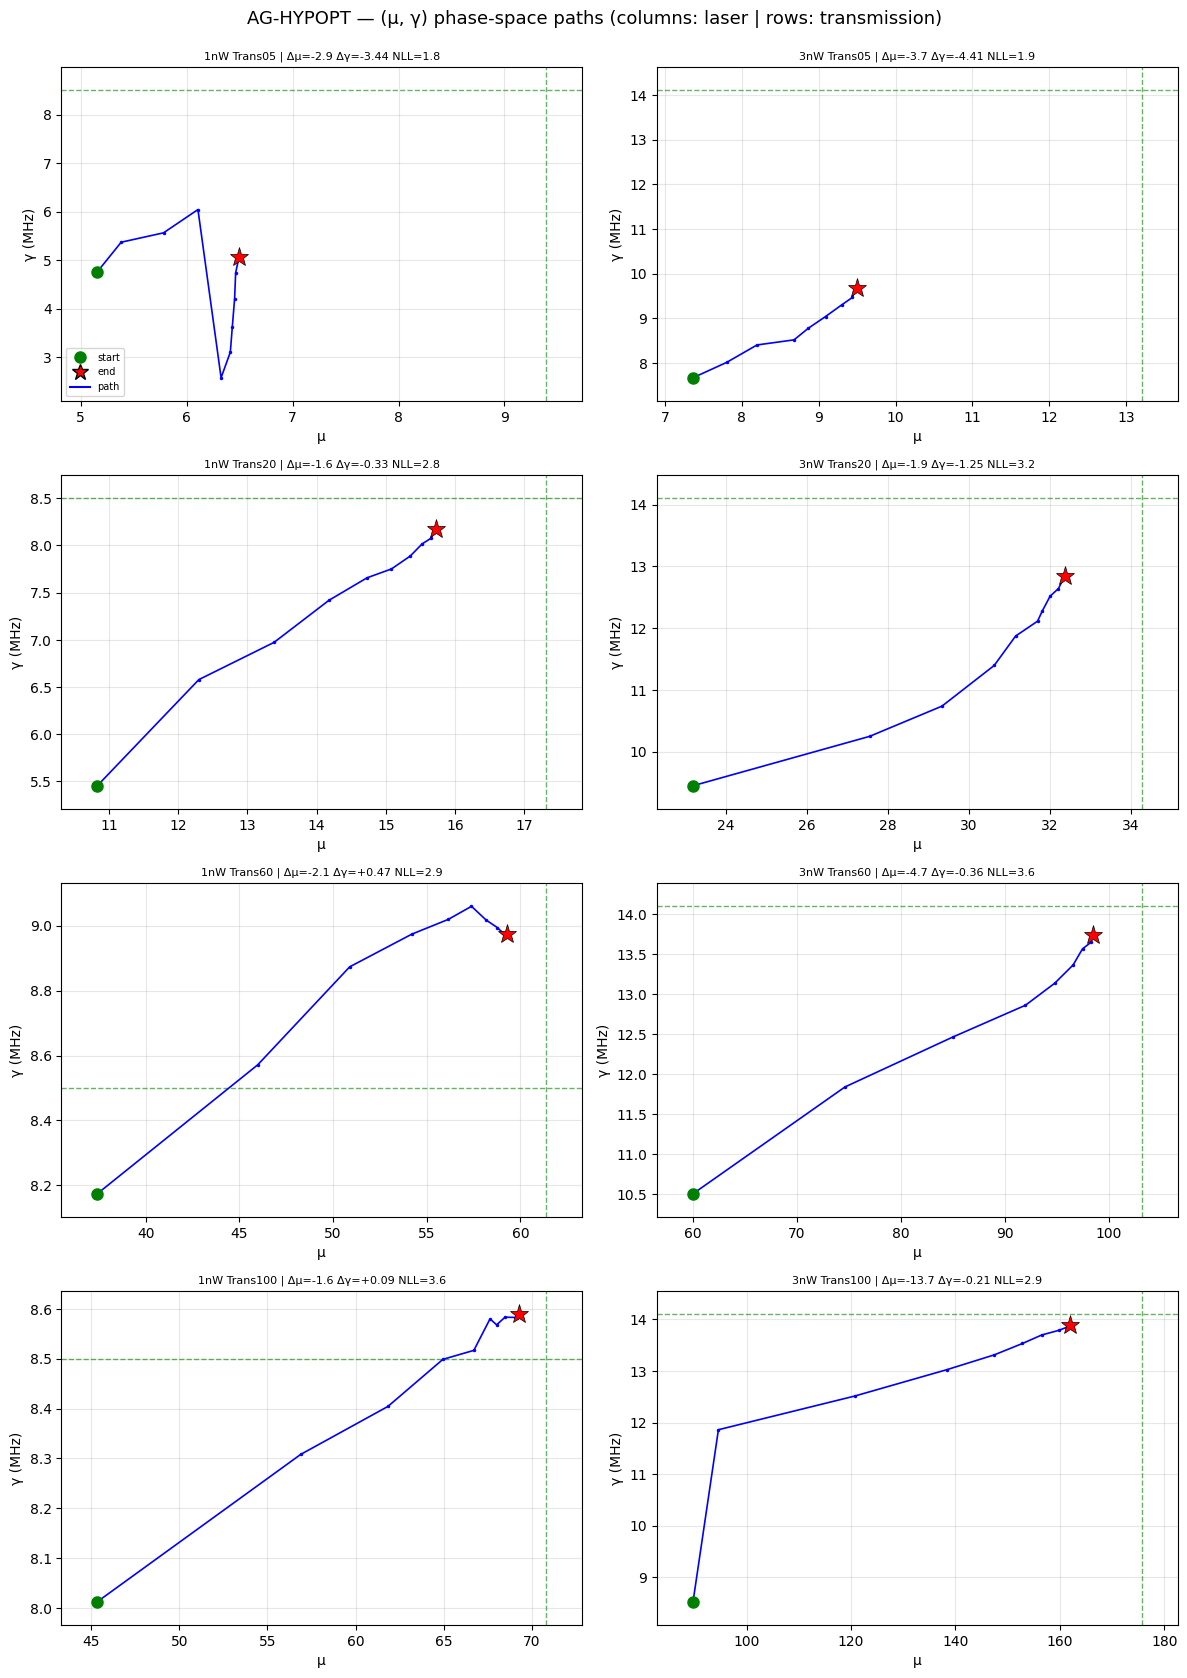

trial finished in 9.4 min
objective = 0.0294 ± 0.0126
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.49   -30.9 |     8.50    5.06   -40.5
1nW Trans20    17.32   15.73    -9.2 |     8.50    8.17    -3.8
1nW Trans60    61.37   59.29    -3.4 |     8.50    8.97    +5.6
1nW Trans100   70.82   69.27    -2.2 |     8.50    8.59    +1.0
3nW Trans05    13.20    9.50   -28.1 |    14.10    9.69   -31.3
3nW Trans20    34.28   32.38    -5.5 |    14.10   12.85    -8.9
3nW Trans60   103.20   98.51    -4.5 |    14.10   13.74    -2.6
3nW Trans100  175.71  161.98    -7.8 |    14.10   13.89    -1.5

μ: RMSE 5.540 (rel 15.6%, bias -4.019) | γ: RMSE 2.042 (rel 18.5%, bias -1.179)


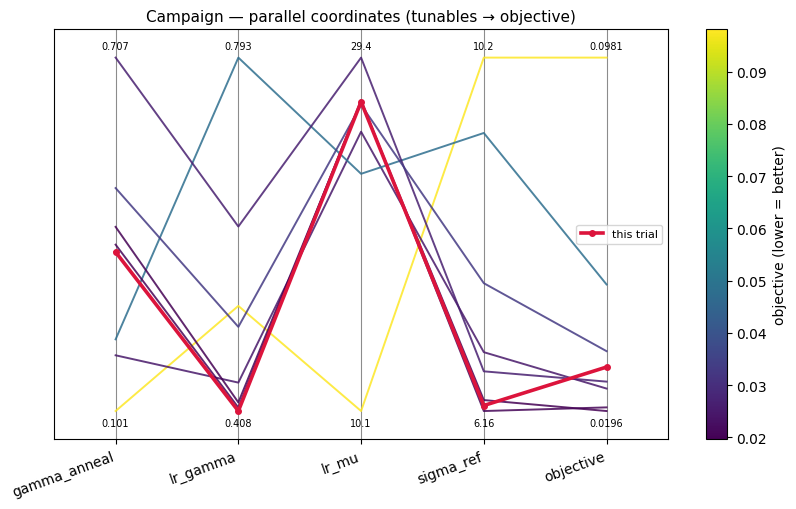

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 08 (sigma_ref 6.22, lr_mu 26.99, lr_gamma 0.408, gamma_anneal 0.373), the highest-ei TPE draw and the centre of the plateau, ran 9.4 min and scored 0.0294 +/- 0.0126, worse than trials 05/07, but with mu at 15.6% - again the plateau floor (mu is 15.3-15.6% across trials 05/06/07/08). The loss difference is entirely gamma: 18.5% here vs 12.6-13.7% in the best trials, driven by an outlier at 1nW Trans05 (gamma_fit 5.06 vs true 8.5, -40.5%; the same scan was -15.9% in trial 05). So while mu is a stable function of (lr_mu, sigma_ref), gamma swings between runs at the low-count Trans05 points, and the objective differences among the plateau configs are within that noise (uncertainties 0.008-0.013). Net: trial 08 confirms the mu floor but does not improve on trial 05; the plateau is genuine and gamma-limited by low-count noise.

**Summary:** Trial 08 (sigma_ref 6.22, lr_mu 26.99, lr_gamma 0.408, gamma_anneal 0.373) scored 0.0294 +/- 0.0126: mu held at the 15.6% floor but gamma jumped to 18.5% on a 1nW Trans05 outlier (-40.5%), so plateau-config differences are within run-to-run noise.
**Key insight:** On the plateau mu is fixed at ~15.3-15.6% while gamma fluctuates 12.6-18.5% at the low-count Trans05 scans; the objective spread among near-optimal configs is dominated by that low-signal gamma noise, not by the tunables.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 08 (sigma_ref 6.22, lr_mu 26.99, lr_gamma 0.408, gamma_anneal 0.373) scored 0.0294 +/- 0.0126: mu held at the 15.6% floor but gamma jumped to 18.5% on a 1nW Trans05 outlier (-40.5%), so plateau-config differences are within run-to-run noise.'
KEY_INSIGHT = 'On the plateau mu is fixed at ~15.3-15.6% while gamma fluctuates 12.6-18.5% at the low-count Trans05 scans; the objective spread among near-optimal configs is dominated by that low-signal gamma noise, not by the tunables.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
